# $(SASA) Regular$

$loss = \alpha \times mse(\hat{\theta_i^a}, \hat{\theta_j^a}) + \beta \times (1-mse(\hat{\theta_i^a}, \hat{\theta_k^b})) + \gamma \times mse(\hat{s_{i+2}^a}, y) + \lambda(\hat{\theta_i^a}^2 + \hat{\theta_k^b}^2 + \hat{\theta_j^a}^2)$

## Experimento Validação

- 100 episódios de Treino
- 10 episódios de Validação
- 1 agente

* Cada agente é treinado com 800 passos dos episódios de treino e testado em 200, os passos de todos os episodios sao embaralhados aleatoriamente
* Resultado intermedário é uma comparacao do parametro estimado em cada passo de teste com o parametro real
* Os a gentes são validados em cada passo dos episódios de validação
* Resultado final é comparacao do parametro estimado em cada passo pelos agentes com o parametro real

In [2]:
import matplotlib.pyplot as plt

from pmbrl.model2 import Model
from pmbrl.data import Experiment_Data, get_data_expanded

# Training

In [3]:
data = Experiment_Data()

data.load(path='training_data.csv')
data.build_training_dataset()

,step,episode,p,s,a,r,s_,a_,r_,s__
1725,20,72,"(0.67, 1.6)","(-0.031, -0.423, -0.021, 0.189)",0,1.0,"(-0.039, -0.612, -0.017, 0.342)",1.0,1.0,"(-0.051, -0.423, -0.011, 0.183)"
2228,24,97,"(0.38, 0.9)","(0.198, 0.765, -0.175, -0.944)",1,1.0,"(0.213, 0.957, -0.194, -1.181)",1.0,1.0,"(0.232, 1.15, -0.218, -1.421)"
2093,11,89,"(0.85, 1.4)","(0.133, 0.992, -0.132, -1.284)",1,1.0,"(0.153, 1.185, -0.157, -1.54)",0.0,1.0,"(0.176, 0.995, -0.188, -1.356)"
1291,11,55,"(0.33, 1.0)","(0.182, 0.614, -0.175, -0.723)",0,1.0,"(0.195, 0.426, -0.189, -0.584)",0.0,1.0,"(0.203, 0.238, -0.201, -0.448)"
1746,41,72,"(0.67, 1.6)","(-0.345, -0.622, 0.189, 0.568)",1,1.0,"(-0.358, -0.435, 0.2, 0.449)",0.0,1.0,"(-0.366, -0.625, 0.209, 0.63)"
...,...,...,...,...,...,...,...,...,...,...
1393,1,61,"(0.36, 0.0)","(-0.012, -0.171, 0.018, 0.389)",0,1.0,"(-0.015, -0.37, 0.025, 0.757)",0.0,1.0,"(-0.023, -0.569, 0.04, 1.128)"
754,17,33,"(0.03, 0.9)","(0.011, -0.184, 0.029, 0.166)",0,1.0,"(0.008, -0.373, 0.032, 0.325)",0.0,1.0,"(0.0, -0.562, 0.039, 0.485)"
537,28,24,"(0.68, 1.3)","(-0.117, -0.408, 0.17, 0.776)",1,1.0,"(-0.125, -0.219, 0.185, 0.622)",1.0,1.0,"(-0.129, -0.031, 0.198, 0.473)"
1803,31,74,"(0.22, 0.7)","(0.236, 0.204, -0.195, -0.435)",0,1.0,"(0.24, 0.014, -0.204, -0.259)",0.0,1.0,"(0.241, -0.175, -0.209, -0.086)"


In [4]:
model = Model()

loss_param=1e-5

x, y = model.get_features_targets(data.training_dataset)
trainer = model.train(x, y, num_epochs=5000, alpha=loss_param, beta=loss_param, lambda_=loss_param)
train_data = data.get_training_data(trainer, inference_schema=model.inference_schema)
train_data.head()

,epoch,mse_positive,mse_negative,mse_s,regularize,transition,reward
0,0,"[0.09150030463933945, 1.2981953620910645]","[0.0899214968085289, 1.2381118535995483]","[0.2073681354522705, 0.24326157569885254, 0.12...",1.915007,1.647816,1.190581
1,1,"[0.0920233428478241, 1.3007298707962036]","[0.09037161618471146, 1.2400505542755127]","[0.2023509293794632, 0.2410118579864502, 0.120...",1.913612,1.630046,1.183988
2,2,"[0.09256806969642639, 1.3032675981521606]","[0.09084542095661163, 1.2419906854629517]","[0.19738979637622833, 0.2388039082288742, 0.11...",1.912261,1.612461,1.177449
3,3,"[0.09313442558050156, 1.3058218955993652]","[0.09134085476398468, 1.2439473867416382]","[0.19249799847602844, 0.23663638532161713, 0.1...",1.910954,1.595058,1.170978
4,4,"[0.09371951967477798, 1.308364748954773]","[0.09185664355754852, 1.2458964586257935]","[0.1876751035451889, 0.23451067507266998, 0.11...",1.909698,1.577834,1.164579


In [5]:
data.training_dataset.head()

,step,episode,p,s,a,r,s_,a_,r_,s__
1725,20,72,"(0.67, 1.6)","(-0.031, -0.423, -0.021, 0.189)",0,1.0,"(-0.039, -0.612, -0.017, 0.342)",1.0,1.0,"(-0.051, -0.423, -0.011, 0.183)"
2228,24,97,"(0.38, 0.9)","(0.198, 0.765, -0.175, -0.944)",1,1.0,"(0.213, 0.957, -0.194, -1.181)",1.0,1.0,"(0.232, 1.15, -0.218, -1.421)"
2093,11,89,"(0.85, 1.4)","(0.133, 0.992, -0.132, -1.284)",1,1.0,"(0.153, 1.185, -0.157, -1.54)",0.0,1.0,"(0.176, 0.995, -0.188, -1.356)"
1291,11,55,"(0.33, 1.0)","(0.182, 0.614, -0.175, -0.723)",0,1.0,"(0.195, 0.426, -0.189, -0.584)",0.0,1.0,"(0.203, 0.238, -0.201, -0.448)"
1746,41,72,"(0.67, 1.6)","(-0.345, -0.622, 0.189, 0.568)",1,1.0,"(-0.358, -0.435, 0.2, 0.449)",0.0,1.0,"(-0.366, -0.625, 0.209, 0.63)"


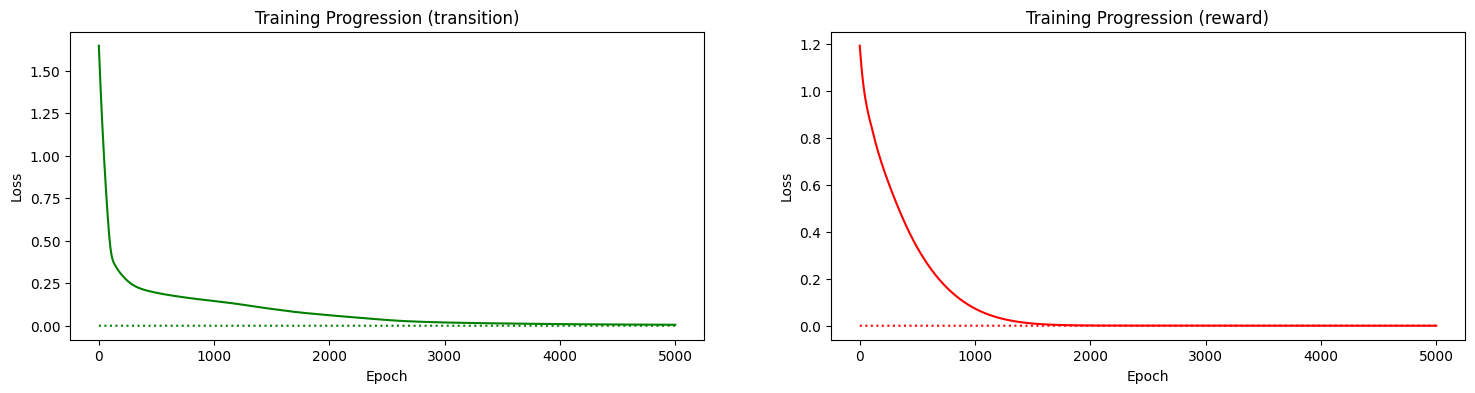

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(18, 4))

data.plot_training_loss(axs[0])
data.plot_training_loss(axs[1], train_data.reward, 'r')

plt.show()

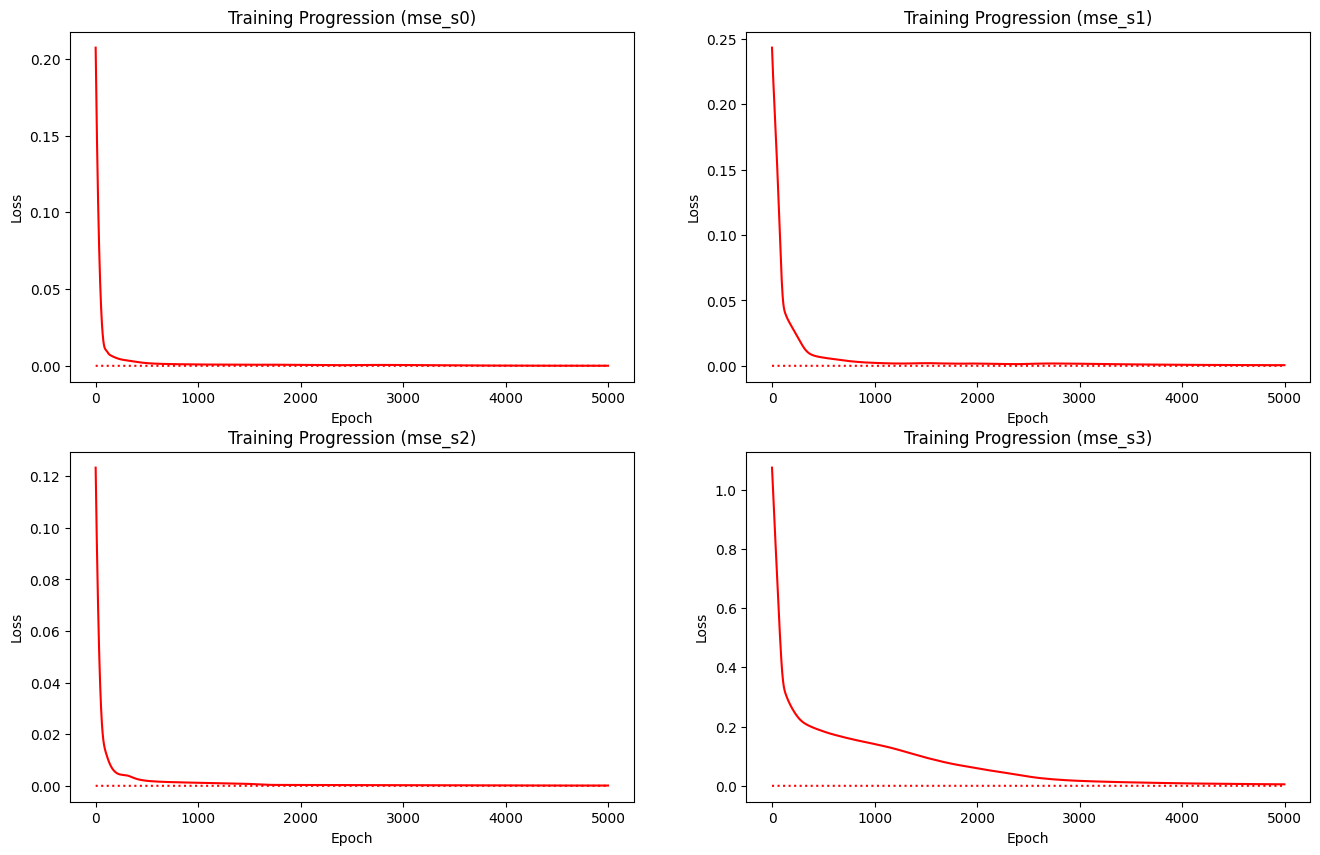

In [7]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
    'mse_negative': ['mse_negative_p0', 'mse_negative_p1'],
    'mse_positive': ['mse_positive_p0', 'mse_positive_p1'],
}

df = get_data_expanded(train_data, expansions)

for i,col in enumerate(expansions['mse_s']):
    data.plot_training_loss(axs[i//2][i%2], df[col], 'r')

plt.show()

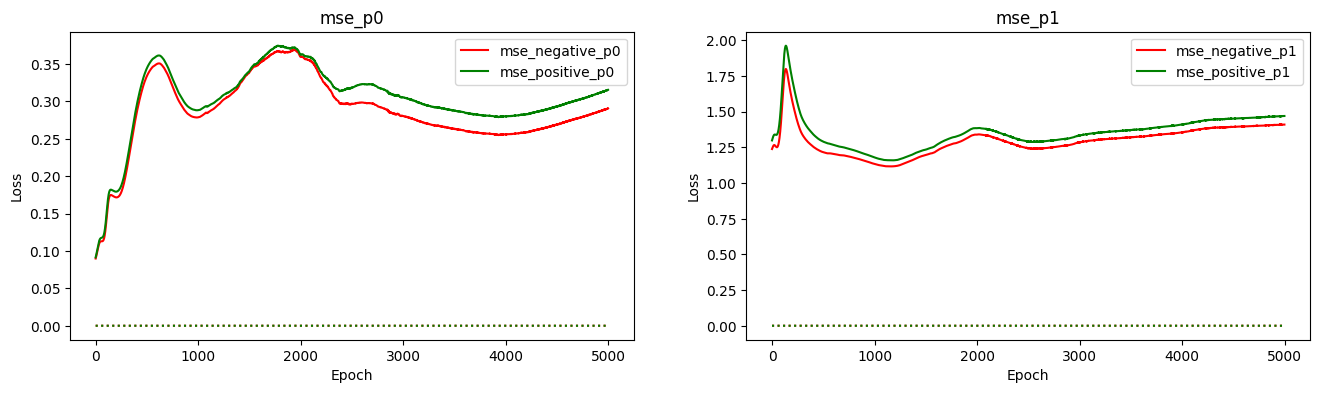

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
    'mse_negative': ['mse_negative_p0', 'mse_negative_p1'],
    'mse_positive': ['mse_positive_p0', 'mse_positive_p1'],
}

df = get_data_expanded(train_data, expansions)

for i,(neg, pos) in enumerate(zip(expansions['mse_negative'], expansions['mse_positive'])):
    data.plot_training_loss(axs[i], df[neg], 'r')
    data.plot_training_loss(axs[i], df[pos], 'g')
    axs[i].set_title(f'mse_p{i}')
    axs[i].legend()

plt.show()

## Params

In [9]:
import pandas as pd

training_params = pd.DataFrame(y.numpy(), columns=model.targets_lables)

expansions = {
    'p': ['p0', 'p1']
}
df_trainning = get_data_expanded(data.training_data.loc[(data.training_data.epoch==499)], expansions)

df_trainning_p = pd.DataFrame([], columns=['epoch', 'positive_p0', 'positive_p1', 'negative_p0', 'negative_p1', 'p0', 'p1'])
for epoch in df_trainning.epoch.unique():
    copy = df_trainning[df_trainning.epoch == epoch].copy()[['epoch', 'p0', 'p1']].reset_index(drop=True)
    copy[['sample', 'positive_p0', 'positive_p1', 'negative_p0', 'negative_p1']] = training_params.copy()[['positive_p0', 'positive_p1', 'negative_p0', 'negative_p1']].reset_index()
    df_trainning_p = pd.concat([df_trainning_p, copy])

df_trainning_p.head()

/tmp/ipykernel_8822/580248604.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_trainning_p = pd.concat([df_trainning_p, copy])


,epoch,positive_p0,positive_p1,negative_p0,negative_p1,p0,p1,sample
0,499,0.67,1.6,0.15,0.8,0.101363,0.203491,0.0
1,499,0.38,0.9,0.22,0.7,0.321273,-0.287493,1.0
2,499,0.85,1.4,0.60,0.7,0.359557,-0.477241,2.0
3,499,0.33,1.0,0.51,0.0,0.250095,-0.014411,3.0
4,499,0.67,1.6,0.68,1.3,-0.045458,0.387937,4.0


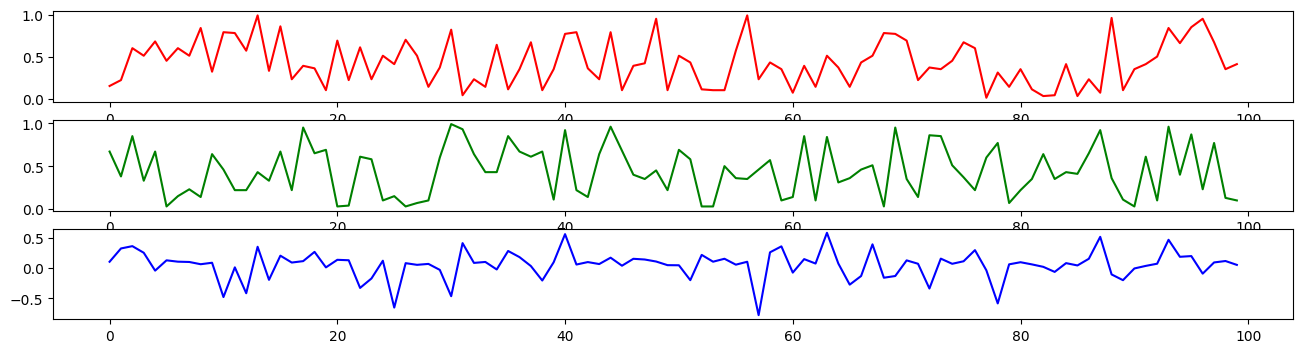

In [10]:
fig, axs = plt.subplots(3, 1, figsize=(16, 4))

axs[0].plot(df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]['negative_p0'], color='r', label='negative')
axs[1].plot(df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]['positive_p0'], color='g', label='positve')
axs[2].plot(df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]['p0'], color='b', label='estimative')

plt.show()

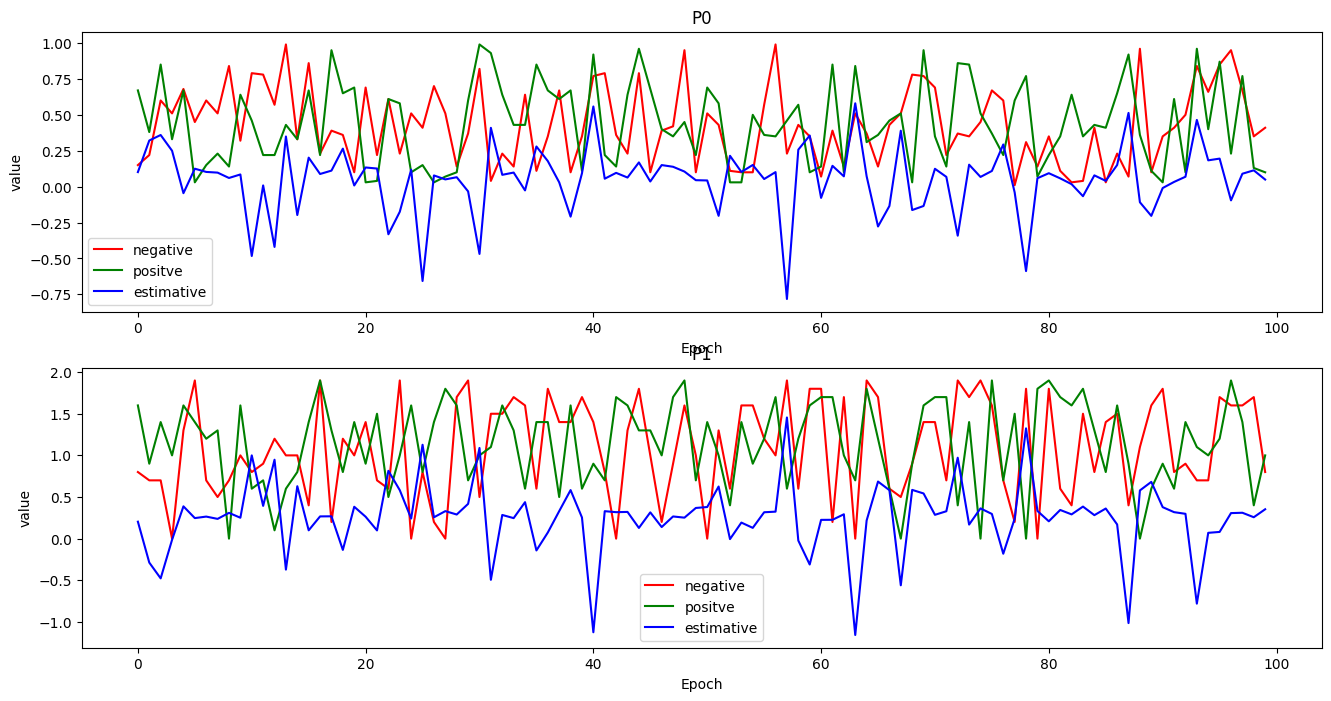

In [11]:
fig, axs = plt.subplots(2,1, figsize=(16, 8))

# df = df_trainning_p.groupby('epoch').mean()
# df = df_trainning_p.groupby('sample').mean()
df = df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]

axs[0].plot(df['negative_p0'], color='r', label='negative')
axs[0].plot(df['positive_p0'], color='g', label='positve')
axs[0].plot(df['p0'], color='b', label='estimative')

axs[0].set_ylabel('value')
axs[0].set_xlabel('Epoch')
axs[0].set_title(f'P0')
axs[0].legend()

axs[1].plot(df['negative_p1'], color='r', label='negative')
axs[1].plot(df['positive_p1'], color='g', label='positve')
axs[1].plot(df['p1'], color='b', label='estimative')

axs[1].set_ylabel('value')
axs[1].set_xlabel('Epoch')
axs[1].set_title(f'P1')
axs[1].legend()

plt.show()

## Best and worst episodes

In [25]:
data.evaluate_model(model, path='training_data.csv')
results = data.get_evaluation_metrics()
results.head()

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:181: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3

,step,episode,p,s,a,r,s_,a_,r_,s__,...,estimated_s3,p0,p1,estimated_p0,estimated_p1,rse_s0,rse_s1,rse_s2,rse_s3,rse_r
0,0,0,"(0.58, 1.0)","(0.02, -0.037, -0.022, 0.009)",0,1.0,"(0.019, -0.229, -0.022, 0.229)",0.0,1.0,"(0.015, -0.421, -0.017, 0.449)",...,0.429,0.58,1.0,0.422,0.092,0.001,0.008,0.001,0.020,0.0
1,1,0,"(0.58, 1.0)","(0.019, -0.229, -0.022, 0.229)",0,1.0,"(0.015, -0.421, -0.017, 0.449)",0.0,1.0,"(0.006, -0.612, -0.008, 0.671)",...,0.662,0.58,1.0,0.415,0.096,0.003,0.012,0.001,0.009,0.0
2,2,0,"(0.58, 1.0)","(0.015, -0.421, -0.017, 0.449)",0,1.0,"(0.006, -0.612, -0.008, 0.671)",0.0,1.0,"(-0.006, -0.804, 0.005, 0.894)",...,0.896,0.58,1.0,0.407,0.100,0.006,0.011,0.003,0.002,0.0
3,3,0,"(0.58, 1.0)","(0.006, -0.612, -0.008, 0.671)",0,1.0,"(-0.006, -0.804, 0.005, 0.894)",1.0,1.0,"(-0.022, -0.612, 0.023, 0.67)",...,0.682,0.58,1.0,0.399,0.105,0.003,0.011,0.000,0.012,0.0
4,4,0,"(0.58, 1.0)","(-0.006, -0.804, 0.005, 0.894)",1,1.0,"(-0.022, -0.612, 0.023, 0.67)",1.0,1.0,"(-0.034, -0.421, 0.036, 0.45)",...,0.458,0.58,1.0,0.708,0.079,0.006,0.039,0.013,0.008,0.0


In [26]:
rmse = results[['episode', 'rse_s0', 'rse_s1', 'rse_s2', 'rse_s3']].groupby('episode').mean().reset_index()
rmse['rmse'] = rmse.rse_s0 + rmse.rse_s1 + rmse.rse_s2 + rmse.rse_s3
rmse_sorted = rmse.sort_values(by='rmse')
epis = rmse.shape[0]

best_episodes = rmse_sorted.head(3).episode.values
worst_episodes = rmse_sorted.tail(3).episode.values
print(f'{best_episodes=}', f'{worst_episodes=}')

best_episodes=array([83,  4, 10]) worst_episodes=array([ 1, 75, 22])


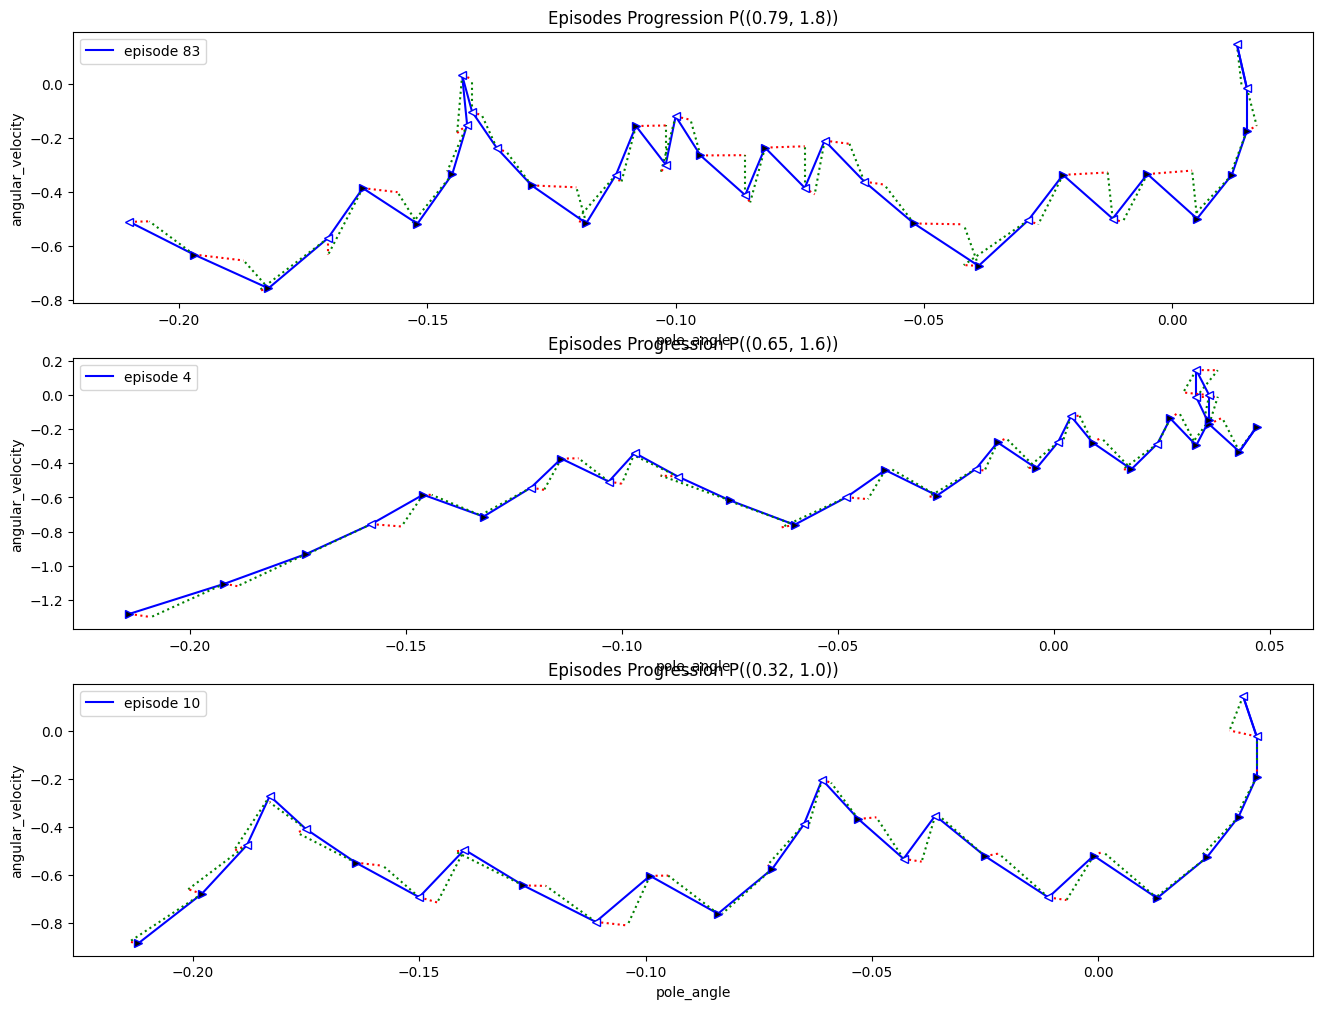

In [27]:
fig, axs = plt.subplots(3, 1, figsize=(16, 12))

for i, epi in enumerate(best_episodes):
    data.plot_episode_progression_with_predictions(axs[i], epi)
plt.show()

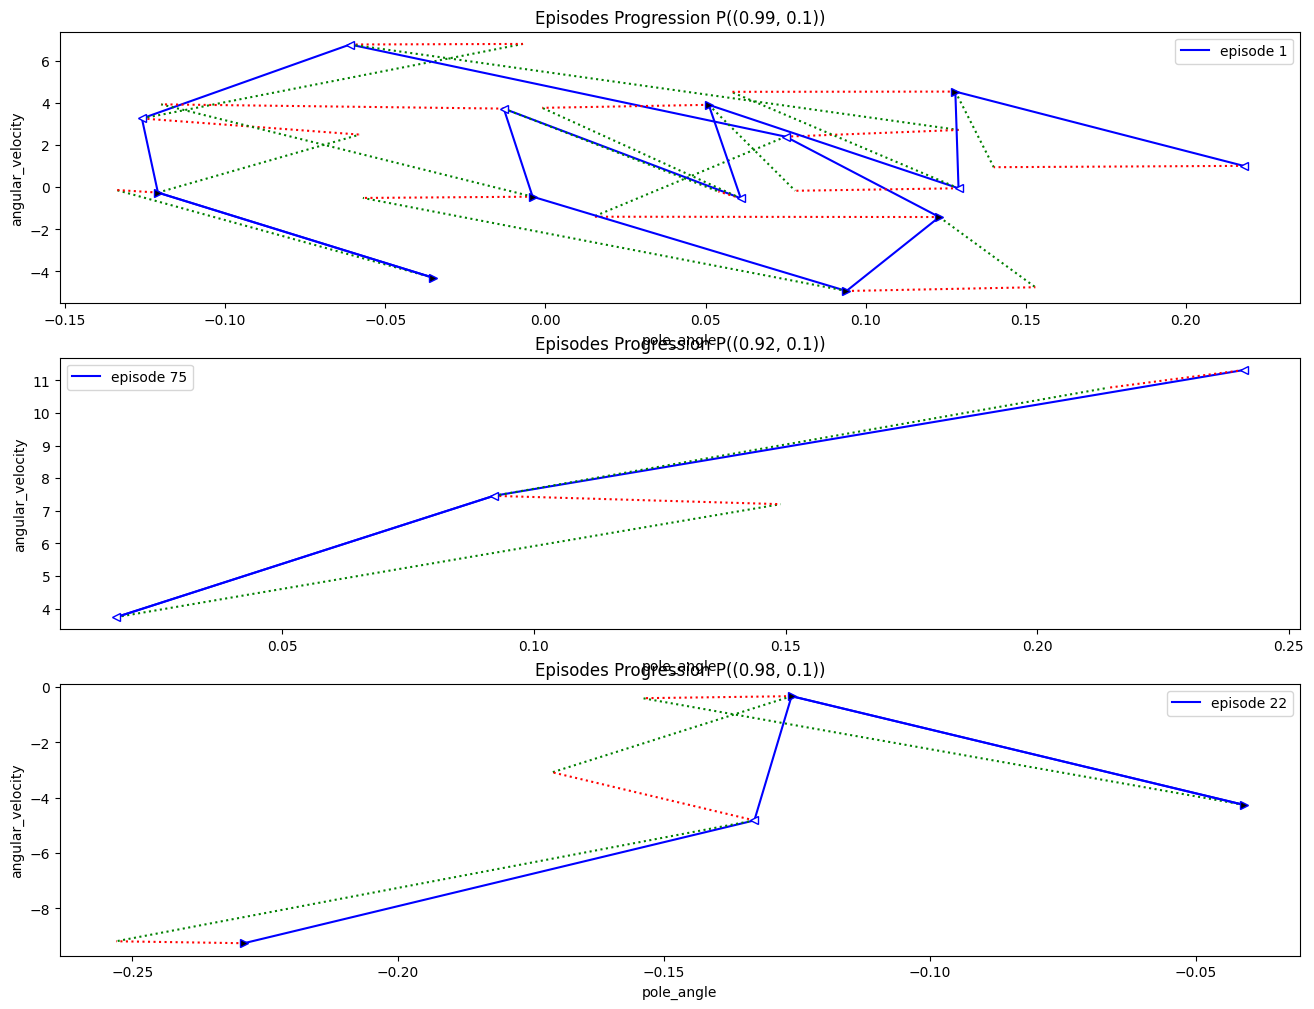

In [28]:
fig, axs = plt.subplots(3, 1, figsize=(16, 12))

for i, epi in enumerate(worst_episodes):
    data.plot_episode_progression_with_predictions(axs[i], epi)
plt.show()

## Kmeans

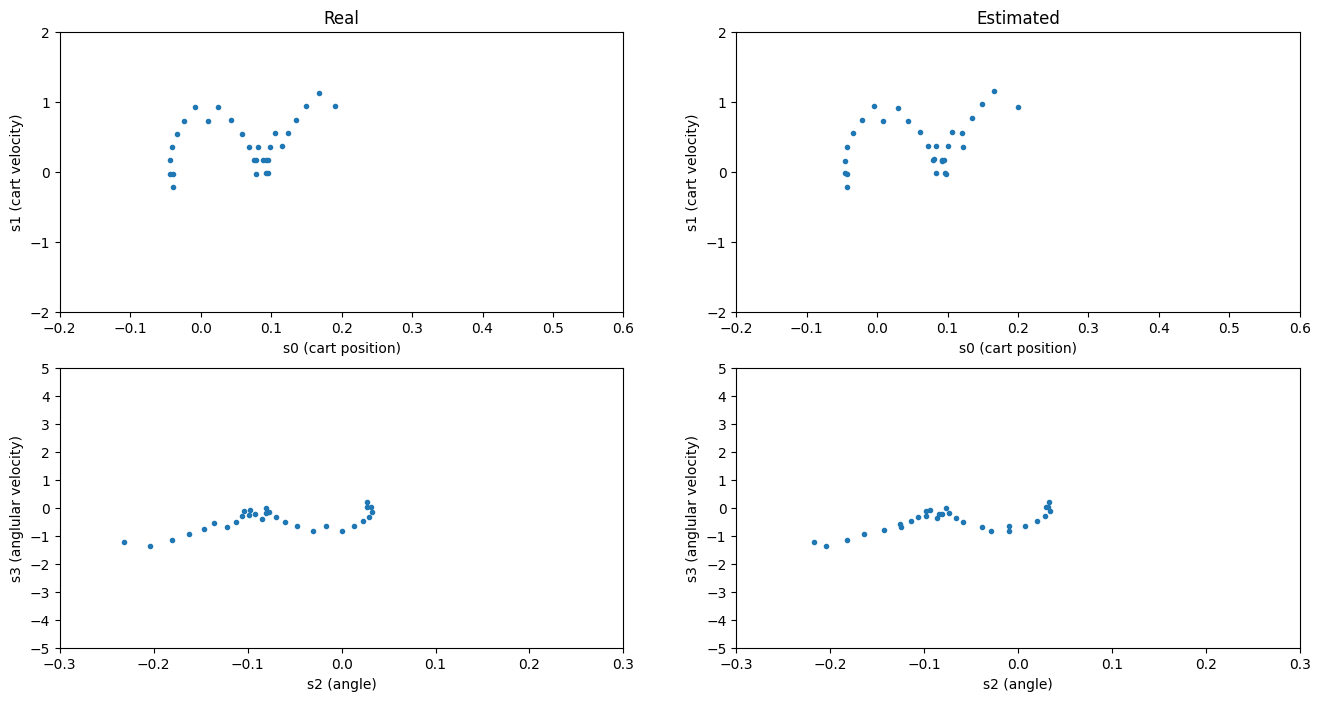

In [29]:
fig, axs = plt.subplots(2, 2, figsize=(16, 8))

df = results.loc[results.episode == 3]

axs[0][0].scatter(x=df['s0'], y=df['s1'], marker='.')
axs[1][0].scatter(x=df['s2'], y=df['s3'], marker='.')

axs[0][1].scatter(x=df['estimated_s0'], y=df['estimated_s1'], marker='.')
axs[1][1].scatter(x=df['estimated_s2'], y=df['estimated_s3'], marker='.')

axs[0][0].set_title('Real')
axs[0][1].set_title('Estimated')

for i, _ in enumerate(axs[0]):
    axs[0][i].set_ylabel('s1 (cart velocity)')
    axs[0][i].set_xlabel('s0 (cart position)')
    axs[0][i].set_yticks(range(-2,3))
    axs[0][i].set_xticks([i/10 for i in range(-2,7)])

for i, _ in enumerate(axs[0]):
    axs[1][i].set_ylabel('s3 (anglular velocity)')
    axs[1][i].set_xlabel('s2 (angle)')
    axs[1][i].set_yticks(range(-5,6))
    axs[1][i].set_xticks([i/10 for i in range(-3,4)])

plt.show()

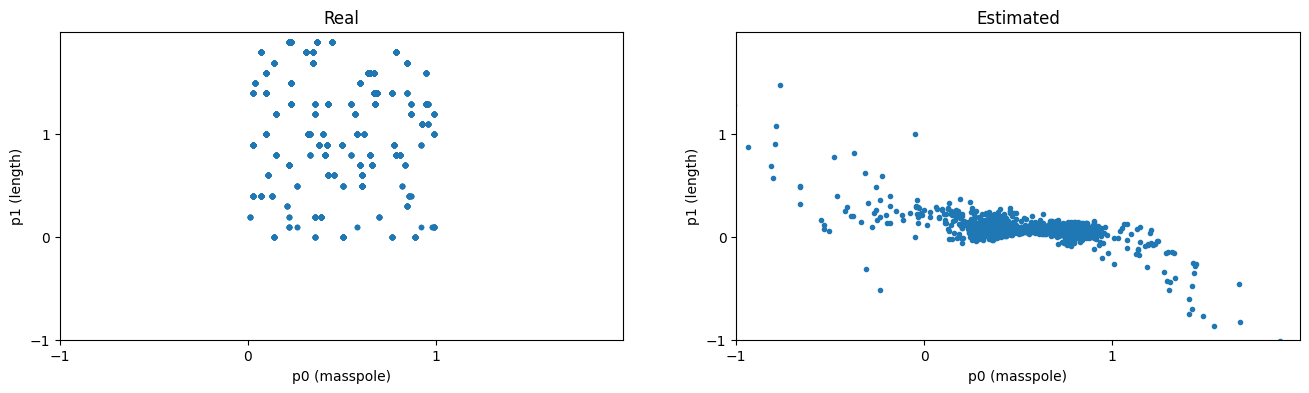

In [37]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))

# df = results.loc[results.episode == 3]
df = results

axs[0].scatter(x=df['p0'], y=df['p1'], marker='.')
axs[1].scatter(x=df['estimated_p0'], y=df['estimated_p1'], marker='.')

axs[0].set_title('Real')
axs[1].set_title('Estimated')

for ax in axs:
    ax.set_ylabel('p1 (length)')
    ax.set_xlabel('p0 (masspole)')
    ax.set_yticks(range(-1,2))
    ax.set_xticks(range(-1,2))
    ax.set_ylim(-1,2)
    ax.set_xlim(-1,2)

plt.show()

In [49]:
from sklearn.cluster import KMeans
import numpy as np

k = 3

X = df[['p0', 'p1']]
kmeans = KMeans(n_clusters=k, random_state=50, n_init="auto").fit(X)
kmeans.labels_
# kmeans.predict([[0, 0], [12, 3]])
# kmeans.cluster_centers_

array([1, 1, 1, ..., 1, 1, 1], dtype=int32)

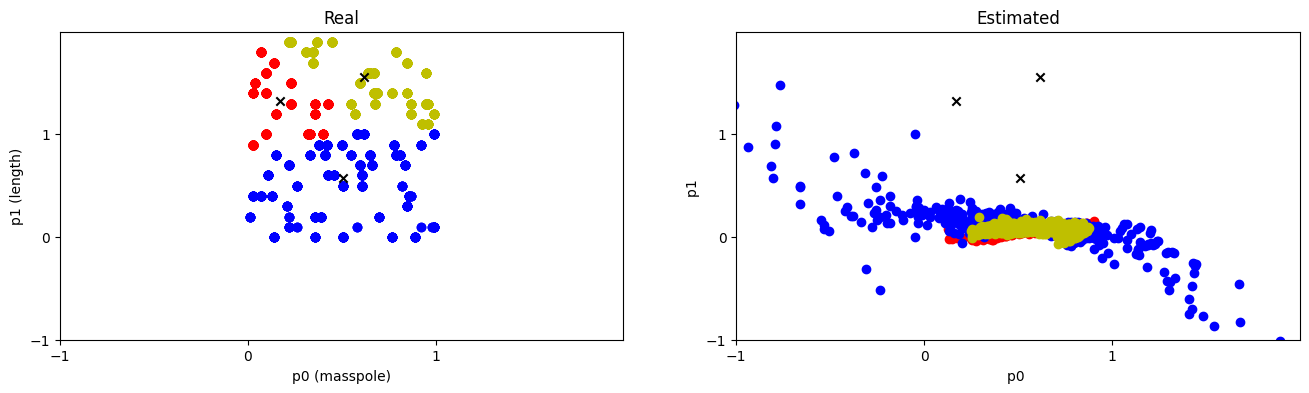

In [50]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))

colors = ['r', 'b', 'y', 'g', 'gray']

for i, label in enumerate(np.unique(kmeans.labels_)):
    cluster_points = X[kmeans.labels_ == label]
    axs[0].scatter(cluster_points['p0'], cluster_points['p1'], color=colors[i])
axs[0].scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], color='black', marker='x')

for i, label in enumerate(np.unique(kmeans.labels_)):
    cluster_points = df[kmeans.labels_ == label]
    axs[1].scatter(cluster_points['estimated_p0'], cluster_points['estimated_p1'], color=colors[i])
axs[1].scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], color='black', marker='x')


axs[0].set_title('Real')
axs[1].set_title('Estimated')

for i, ax in enumerate(axs):
    ax.set_ylabel(f'p1 {"(length)" if i==0 else ""}')
    ax.set_xlabel(f'p0 {"(masspole)" if i==0 else ""}')
    ax.set_yticks(range(-1,2))
    ax.set_xticks(range(-1,2))
    ax.set_ylim(-1,2)
    ax.set_xlim(-1,2)

plt.show()

# Evaluation

In [20]:
data.evaluate_model(model, path='testing_data.csv')
results = data.get_evaluation_metrics()
results.head()

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:181: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3

,step,episode,p,s,a,r,s_,a_,r_,s__,...,estimated_s3,p0,p1,estimated_p0,estimated_p1,rse_s0,rse_s1,rse_s2,rse_s3,rse_r
0,0,0,"(0.62, 1.2)","(-0.005, -0.042, -0.019, -0.009)",0,1.0,"(-0.006, -0.233, -0.02, 0.183)",1.0,1.0,"(-0.01, -0.042, -0.016, -0.018)",...,-0.012,0.62,1.2,0.435,0.088,0.002,0.000,0.001,0.006,0.0
1,1,0,"(0.62, 1.2)","(-0.006, -0.233, -0.02, 0.183)",1,1.0,"(-0.01, -0.042, -0.016, -0.018)",1.0,1.0,"(-0.011, 0.149, -0.016, -0.218)",...,-0.183,0.62,1.2,0.701,0.067,0.000,0.004,0.002,0.035,0.0
2,2,0,"(0.62, 1.2)","(-0.01, -0.042, -0.016, -0.018)",1,1.0,"(-0.011, 0.149, -0.016, -0.218)",1.0,1.0,"(-0.008, 0.34, -0.021, -0.418)",...,-0.387,0.62,1.2,0.711,0.066,0.000,0.005,0.001,0.031,0.0
3,3,0,"(0.62, 1.2)","(-0.011, 0.149, -0.016, -0.218)",1,1.0,"(-0.008, 0.34, -0.021, -0.418)",1.0,1.0,"(-0.001, 0.531, -0.029, -0.619)",...,-0.596,0.62,1.2,0.721,0.064,0.000,0.012,0.001,0.023,0.0
4,4,0,"(0.62, 1.2)","(-0.008, 0.34, -0.021, -0.418)",1,1.0,"(-0.001, 0.531, -0.029, -0.619)",1.0,1.0,"(0.009, 0.722, -0.041, -0.822)",...,-0.809,0.62,1.2,0.733,0.063,0.002,0.016,0.003,0.013,0.0


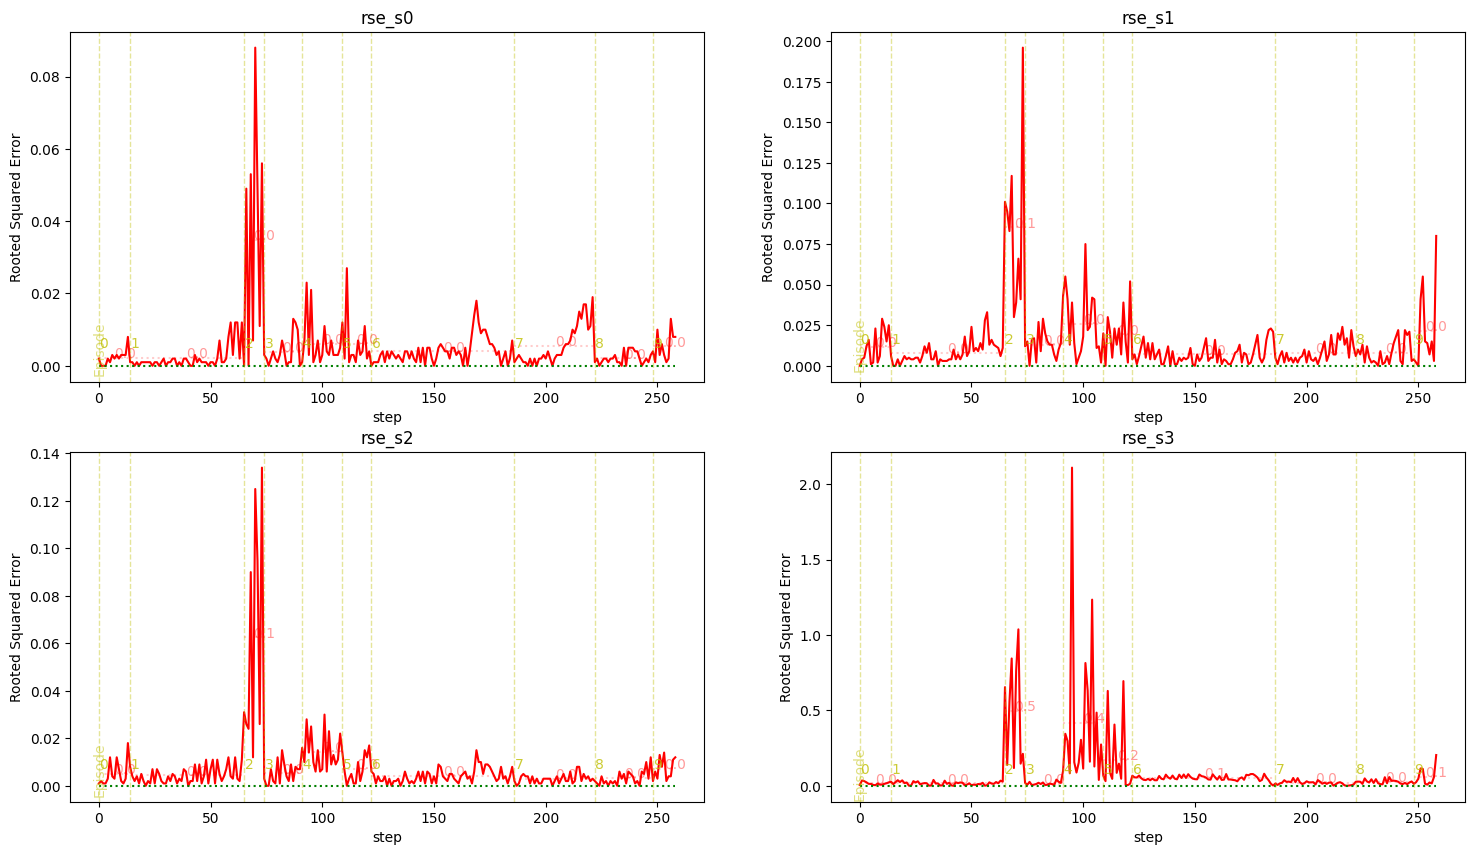

In [21]:
fig, axs = plt.subplots(2, 2, figsize=(18,10))

data.plot_value_through_episodes(axs[0][0], results, 'rse_s0')
data.plot_value_through_episodes(axs[0][1], results, 'rse_s1')
data.plot_value_through_episodes(axs[1][0], results, 'rse_s2')
data.plot_value_through_episodes(axs[1][1], results, 'rse_s3')

plt.show()

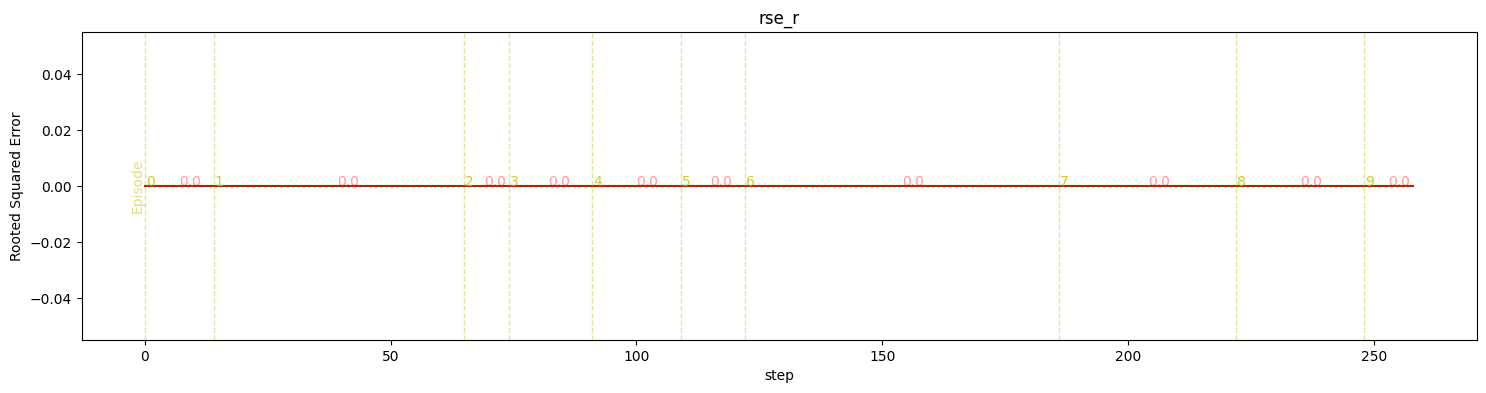

In [22]:
fig, axs = plt.subplots(1, 1, figsize=(18,4))
data.plot_value_through_episodes(axs, results, 'rse_r')
plt.show()

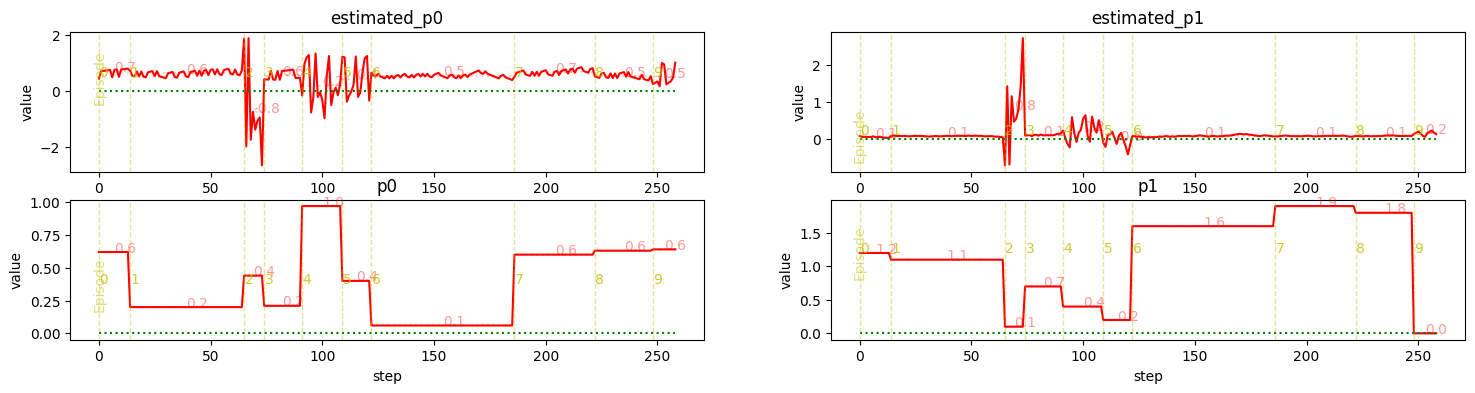

In [23]:
fig, axs = plt.subplots(2, 2, figsize=(18,4))
data.plot_value_through_episodes(axs[0][0], results, 'estimated_p0', y_label='value')
data.plot_value_through_episodes(axs[0][1], results, 'estimated_p1', y_label='value')
data.plot_value_through_episodes(axs[1][0], results, 'p0', y_label='value')
data.plot_value_through_episodes(axs[1][1], results, 'p1', y_label='value')
plt.show()

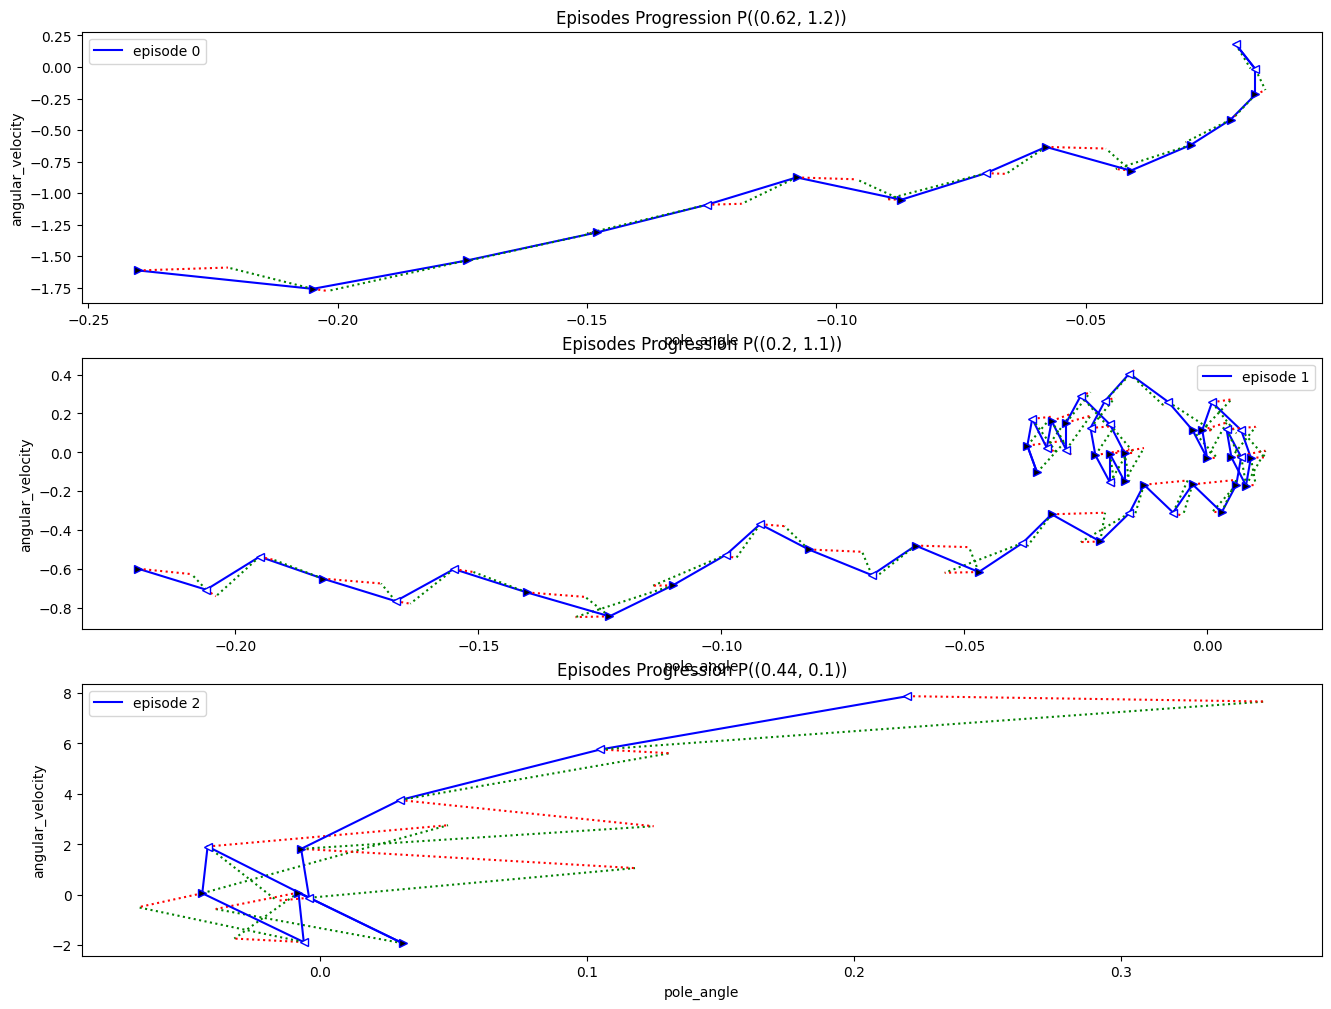

In [24]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(16, 12))
data.plot_episode_progression_with_predictions(axs[0], 0)
data.plot_episode_progression_with_predictions(axs[1], 1)
data.plot_episode_progression_with_predictions(axs[2], 2)
plt.show()